# ML - Supervised Learning
## K-Nearest Neighbors (KNN)

### Problem Statement 1: Student Performance Prediction ###
**Approach: Dataset → Scaling → New Student → Distance → Sort → K nearest → Voting → Prediction**

In [1]:
# Import libraries
import numpy as np
import pandas as pd

In [2]:
# Create 30 student records
data = {
    "Student": [
        "S1", "S2", "S3", "S4", "S5",
        "S6", "S7", "S8", "S9", "S10",
        "S11", "S12", "S13", "S14", "S15",
        "S16", "S17", "S18", "S19", "S20",
        "S21", "S22", "S23", "S24", "S25",
        "S26", "S27", "S28", "S29", "S30"
    ],

    "study_hours": [
        1, 2, 2, 3, 3,
        4, 4, 5, 5, 6,
        6, 7, 7, 8, 8,
        9, 9, 10, 10, 11,
        1, 2, 3, 4, 5,
        6, 7, 8, 9, 10
    ],

    "Attendance": [
        50, 55, 60, 62, 65,
        68, 70, 72, 75, 78,
        80, 82, 85, 88, 90,
        92, 94, 95, 96, 98,
        52, 58, 64, 69, 74,
        79, 84, 89, 93, 97
    ],
    "Pass": [
        0, 0, 0, 0, 0,
        0, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        0, 0, 0, 0, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)
print("Student Dataset")
print(df)

Student Dataset
   Student  study_hours  Attendance  Pass
0       S1            1          50     0
1       S2            2          55     0
2       S3            2          60     0
3       S4            3          62     0
4       S5            3          65     0
5       S6            4          68     0
6       S7            4          70     1
7       S8            5          72     1
8       S9            5          75     1
9      S10            6          78     1
10     S11            6          80     1
11     S12            7          82     1
12     S13            7          85     1
13     S14            8          88     1
14     S15            8          90     1
15     S16            9          92     1
16     S17            9          94     1
17     S18           10          95     1
18     S19           10          96     1
19     S20           11          98     1
20     S21            1          52     0
21     S22            2          58     0
22     S23        

In [3]:
# Select features
study_hours = df["study_hours"]
attendance = df["Attendance"]

print("\nStudy Hours:")
print(study_hours.tolist())

print("\nAttendance:")
print(attendance.tolist())


Study Hours:
[1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 11, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Attendance:
[50, 55, 60, 62, 65, 68, 70, 72, 75, 78, 80, 82, 85, 88, 90, 92, 94, 95, 96, 98, 52, 58, 64, 69, 74, 79, 84, 89, 93, 97]


In [4]:
# Select target
Pass = df["Pass"]

print("\nPass/Fail:")
print(Pass.tolist())


Pass/Fail:
[0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1]


In [5]:
# Feature Scaling - Min-Max Scaling
study_min = study_hours.min()
study_max = study_hours.max()

att_min = attendance.min()
att_max = attendance.max()

df["study_scaled"] = (
    (df["study_hours"] - study_min) /
    (study_max - study_min)
)

df["att_scaled"] = (
    (df["Attendance"] - att_min) /
    (att_max - att_min)
)

print("\nScaled Dataset")
print(df)

# X_min = X.min(axis=0)
# X_max = X.max(axis=0)

# X_scaled = (X - X_min) / (X_max - X_min)
# print(X_scaled)


Scaled Dataset
   Student  study_hours  Attendance  Pass  study_scaled  att_scaled
0       S1            1          50     0           0.0    0.000000
1       S2            2          55     0           0.1    0.104167
2       S3            2          60     0           0.1    0.208333
3       S4            3          62     0           0.2    0.250000
4       S5            3          65     0           0.2    0.312500
5       S6            4          68     0           0.3    0.375000
6       S7            4          70     1           0.3    0.416667
7       S8            5          72     1           0.4    0.458333
8       S9            5          75     1           0.4    0.520833
9      S10            6          78     1           0.5    0.583333
10     S11            6          80     1           0.5    0.625000
11     S12            7          82     1           0.6    0.666667
12     S13            7          85     1           0.6    0.729167
13     S14            8         

In [6]:
# New student
new_stu = np.array([8, 90])

new_study_scaled = (
    (new_stu[0] - study_min) /
    (study_max - study_min)
)

new_att_scaled = (
    (new_stu[1] - att_min) /
    (att_max - att_min)
)

print("\nNew Student Scaled Values")
print("Study Hours:", new_study_scaled)
print("Attendance:", new_att_scaled)


New Student Scaled Values
Study Hours: 0.7
Attendance: 0.8333333333333334


In [7]:
# Calculate Distance
df["Distance"] = np.sqrt(
    (df["study_scaled"] - new_study_scaled) ** 2 +
    (df["att_scaled"] - new_att_scaled) ** 2
)

print("\nDistance from New Student")
print(df[["Student", "study_hours", "Attendance", "Pass", "Distance"]])


Distance from New Student
   Student  study_hours  Attendance  Pass  Distance
0       S1            1          50     0  1.088322
1       S2            2          55     0  0.944290
2       S3            2          60     0  0.866386
3       S4            3          62     0  0.768295
4       S5            3          65     0  0.721988
5       S6            4          68     0  0.608333
6       S7            4          70     1  0.577591
7       S8            5          72     1  0.480234
8       S9            5          75     1  0.433193
9      S10            6          78     1  0.320156
10     S11            6          80     1  0.288795
11     S12            7          82     1  0.194365
12     S13            7          85     1  0.144398
13     S14            8          88     1  0.041667
14     S15            8          90     1  0.000000
15     S16            9          92     1  0.108333
16     S17            9          94     1  0.130171
17     S18           10          95  

In [8]:
# Sort students by distance
df_sorted = df.sort_values("Distance")

print("\nStudents Sorted by Distance")
print(df_sorted[["Student","study_hours","Attendance","Pass","Distance"]])


Students Sorted by Distance
   Student  study_hours  Attendance  Pass  Distance
14     S15            8          90     1  0.000000
27     S28            8          89     1  0.020833
13     S14            8          88     1  0.041667
15     S16            9          92     1  0.108333
28     S29            9          93     1  0.117925
16     S17            9          94     1  0.130171
12     S13            7          85     1  0.144398
26     S27            7          84     1  0.160078
11     S12            7          82     1  0.194365
17     S18           10          95     1  0.225501
18     S19           10          96     1  0.235850
29     S30           10          97     1  0.247522
10     S11            6          80     1  0.288795
25     S26            6          79     1  0.304167
9      S10            6          78     1  0.320156
19     S20           11          98     1  0.343188
8       S9            5          75     1  0.433193
24     S25            5          74

In [9]:
# Select K nearest student
k = 3

nearest_students = df_sorted.head(k)

print("\nK Nearest Students")
print(
    nearest_students[
        ["Student", "study_hours", "Attendance", "Pass", "Distance"]
    ]
)


K Nearest Students
   Student  study_hours  Attendance  Pass  Distance
14     S15            8          90     1  0.000000
27     S28            8          89     1  0.020833
13     S14            8          88     1  0.041667


In [10]:
# Take pass/fail votes
votes = nearest_students["Pass"]

print("\nVotes:")
print(votes.tolist())

#Majority voting
pass_votes = sum(votes == 1)
fail_votes = sum(votes == 0)

print("\nPass Votes:", pass_votes)
print("Fail Votes:", fail_votes)



Votes:
[1, 1, 1]

Pass Votes: 3
Fail Votes: 0


In [11]:
# Final prediction
if pass_votes > fail_votes:
    prediction = 1
    result = "PASS"
else:
    prediction = 0
    result = "FAIL"

print("\nFinal Prediction")
print("Prediction:", prediction)
print("Student will:", result)


Final Prediction
Prediction: 1
Student will: PASS


In [13]:
# New student input
new_students = pd.DataFrame({
    "Student": ["N1", "N2", "N3", "N4", "N5"],
    "study_hours": [8, 1, 6, 2, 9],
    "Attendance": [90, 30, 80, 45, 70]
})

# Scale new students using the same Min-Max values
new_students["study_scaled"] = (
    (new_students["study_hours"] - study_min) /
    (study_max - study_min)
)

new_students["att_scaled"] = (
    (new_students["Attendance"] - att_min) /
    (att_max - att_min)
)


results = []

for _, new_stu in new_students.iterrows():

    df["Distance"] = np.sqrt(
        (df["study_scaled"] - new_stu["study_scaled"])**2 +
        (df["att_scaled"] - new_stu["att_scaled"])**2
    )

    row = [new_stu["Student"]]

    for k in [3, 5]:
        nearest = df.sort_values("Distance").head(k)
        prediction = "PASS" if sum(nearest["Pass"]) > k/2 else "FAIL"
        row.append(prediction)

    results.append(row)

result_df = pd.DataFrame(
    results,
    columns=["Student", "K=3", "K=5"]
)

print(result_df.to_string(index=False))

Student  K=3  K=5
     N1 PASS PASS
     N2 FAIL FAIL
     N3 PASS PASS
     N4 FAIL FAIL
     N5 PASS PASS


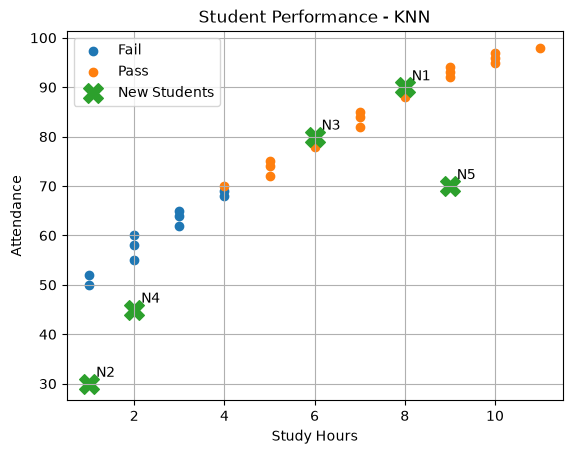

In [14]:
# Data visualization
import matplotlib.pyplot as plt

# Fail = 0
fail = df[df["Pass"] == 0]

# Pass = 1
pass_students = df[df["Pass"] == 1]

# Existing students
plt.scatter(
    fail["study_hours"],
    fail["Attendance"],
    label="Fail"
)

plt.scatter(
    pass_students["study_hours"],
    pass_students["Attendance"],
    label="Pass"
)

# New students
plt.scatter(
    new_students["study_hours"],
    new_students["Attendance"],
    marker="X",
    s=200,
    label="New Students"
)

# Add student names
for _, student in new_students.iterrows():
    plt.annotate(
        student["Student"],
        (student["study_hours"], student["Attendance"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Study Hours")
plt.ylabel("Attendance")
plt.title("Student Performance - KNN")
plt.legend()
plt.grid(True)

plt.show()

### Problem Statement 2: Person Fitness Prediction ###
**Approach: KNN = Find the nearest people → Look at their labels → Take the majority → Make the prediction.**

In [15]:
# Create Dataset
data = {
    "Person": [
        "P1", "P2", "P3", "P4", "P5",
        "P6", "P7", "P8", "P9", "P10",
        "P11", "P12", "P13", "P14", "P15",
        "P16", "P17", "P18", "P19", "P20",
        "P21", "P22", "P23", "P24", "P25",
        "P26", "P27", "P28", "P29", "P30"
    ],

    "Exercise_Hours": [
        0.5, 1.0, 1.0, 1.5, 1.5,
        2.0, 2.0, 2.5, 2.5, 3.0,
        3.0, 3.5, 3.5, 4.0, 4.0,
        4.5, 4.5, 5.0, 5.0, 5.5,
        0.5, 1.0, 1.5, 2.0, 2.5,
        3.0, 3.5, 4.0, 4.5, 5.0
    ],

    "Daily_Steps": [
        2500, 3000, 3500, 4000, 4500,
        5000, 5500, 6000, 6500, 7000,
        7500, 8000, 8500, 9000, 9500,
        10000, 10500, 11000, 11500, 12000,
        2800, 3800, 4300, 5200, 6800,
        7800, 8800, 9800, 10800, 11800
    ],

    "Fit": [
        0, 0, 0, 0, 0,
        0, 0, 1, 1, 1,
        1, 1, 1, 1, 1,
        1, 1, 1, 1, 1,
        0, 0, 0, 0, 1,
        1, 1, 1, 1, 1
    ]
}

df = pd.DataFrame(data)

print("Original Dataset")
print(df)


Original Dataset
   Person  Exercise_Hours  Daily_Steps  Fit
0      P1             0.5         2500    0
1      P2             1.0         3000    0
2      P3             1.0         3500    0
3      P4             1.5         4000    0
4      P5             1.5         4500    0
5      P6             2.0         5000    0
6      P7             2.0         5500    0
7      P8             2.5         6000    1
8      P9             2.5         6500    1
9     P10             3.0         7000    1
10    P11             3.0         7500    1
11    P12             3.5         8000    1
12    P13             3.5         8500    1
13    P14             4.0         9000    1
14    P15             4.0         9500    1
15    P16             4.5        10000    1
16    P17             4.5        10500    1
17    P18             5.0        11000    1
18    P19             5.0        11500    1
19    P20             5.5        12000    1
20    P21             0.5         2800    0
21    P22      

In [16]:
# Select features
exercise = df["Exercise_Hours"]
steps = df["Daily_Steps"]

target = df["Fit"]

In [17]:
# Min-max Scaling
exercise_min = exercise.min()
exercise_max = exercise.max()

steps_min = steps.min()
steps_max = steps.max()

df["Exercise_Scaled"] = (
    (df["Exercise_Hours"] - exercise_min) /
    (exercise_max - exercise_min)
)

df["Steps_Scaled"] = (
    (df["Daily_Steps"] - steps_min) /
    (steps_max - steps_min)
)

print("\nScaled Dataset")
print(df)



Scaled Dataset
   Person  Exercise_Hours  Daily_Steps  Fit  Exercise_Scaled  Steps_Scaled
0      P1             0.5         2500    0              0.0      0.000000
1      P2             1.0         3000    0              0.1      0.052632
2      P3             1.0         3500    0              0.1      0.105263
3      P4             1.5         4000    0              0.2      0.157895
4      P5             1.5         4500    0              0.2      0.210526
5      P6             2.0         5000    0              0.3      0.263158
6      P7             2.0         5500    0              0.3      0.315789
7      P8             2.5         6000    1              0.4      0.368421
8      P9             2.5         6500    1              0.4      0.421053
9     P10             3.0         7000    1              0.5      0.473684
10    P11             3.0         7500    1              0.5      0.526316
11    P12             3.5         8000    1              0.6      0.578947
12    P13

In [18]:
# Create five new people
new_people = pd.DataFrame({

    "Person": [
        "New Person 1",
        "New Person 2",
        "New Person 3",
        "New Person 4",
        "New Person 5"
    ],

    "Exercise_Hours": [
        4.5,    # Positive
        3.0,    # Positive
        0.5,    # Negative
        1.0,    # Negative
        2.5     # Borderline
    ],

    "Daily_Steps": [
        10000,  # Positive
        8000,   # Positive
        2500,   # Negative
        3500,   # Negative
        6500    # Borderline
    ]
})

print("\nNew People")
print(new_people)


New People
         Person  Exercise_Hours  Daily_Steps
0  New Person 1             4.5        10000
1  New Person 2             3.0         8000
2  New Person 3             0.5         2500
3  New Person 4             1.0         3500
4  New Person 5             2.5         6500


In [19]:
# Scale new people
new_people["Exercise_Scaled"] = (
    (new_people["Exercise_Hours"] - exercise_min) /
    (exercise_max - exercise_min)
)
print(new_people['Exercise_Scaled'])

new_people["Steps_Scaled"] = (
    (new_people["Daily_Steps"] - steps_min) /
    (steps_max - steps_min)
)
print(new_people['Steps_Scaled'])

0    0.8
1    0.5
2    0.0
3    0.1
4    0.4
Name: Exercise_Scaled, dtype: float64
0    0.789474
1    0.578947
2    0.000000
3    0.105263
4    0.421053
Name: Steps_Scaled, dtype: float64


In [20]:
# KNN function
def knn_predict(new_exercise, new_steps, k):

    # Calculate Euclidean Distance
    df["Distance"] = np.sqrt(
        (df["Exercise_Scaled"] - new_exercise) ** 2 +
        (df["Steps_Scaled"] - new_steps) ** 2
    )

    # Sort by distance
    sorted_df = df.sort_values("Distance")

    # Select K nearest people
    nearest_people = sorted_df.head(k)

    # Get Fit / Not Fit votes
    votes = nearest_people["Fit"]

    # Count votes
    fit_votes = sum(votes == 1)
    not_fit_votes = sum(votes == 0)

    # Majority voting
    if fit_votes > not_fit_votes:
        prediction = 1
        result = "Fit"
    else:
        prediction = 0
        result = "Not Fit"

    return prediction, result, nearest_people

In [21]:
# Predict for K=3 and K=5
results = []

for index, person in new_people.iterrows():

    # K = 3
    prediction_3, result_3, nearest_3 = knn_predict(
        person["Exercise_Scaled"],
        person["Steps_Scaled"],
        3
    )

    # K = 5
    prediction_5, result_5, nearest_5 = knn_predict(
        person["Exercise_Scaled"],
        person["Steps_Scaled"],
        5
    )

    results.append({
        "Person": person["Person"],
        "Exercise Hours": person["Exercise_Hours"],
        "Daily Steps": person["Daily_Steps"],
        "K=3": result_3,
        "K=5": result_5
    })


In [22]:
# Comparision table
result_df = pd.DataFrame(results)

print("KNN FITNESS PREDICTION")
print("========================================")

print(result_df.to_string(index=False))

KNN FITNESS PREDICTION
      Person  Exercise Hours  Daily Steps     K=3     K=5
New Person 1             4.5        10000     Fit     Fit
New Person 2             3.0         8000     Fit     Fit
New Person 3             0.5         2500 Not Fit Not Fit
New Person 4             1.0         3500 Not Fit Not Fit
New Person 5             2.5         6500     Fit     Fit


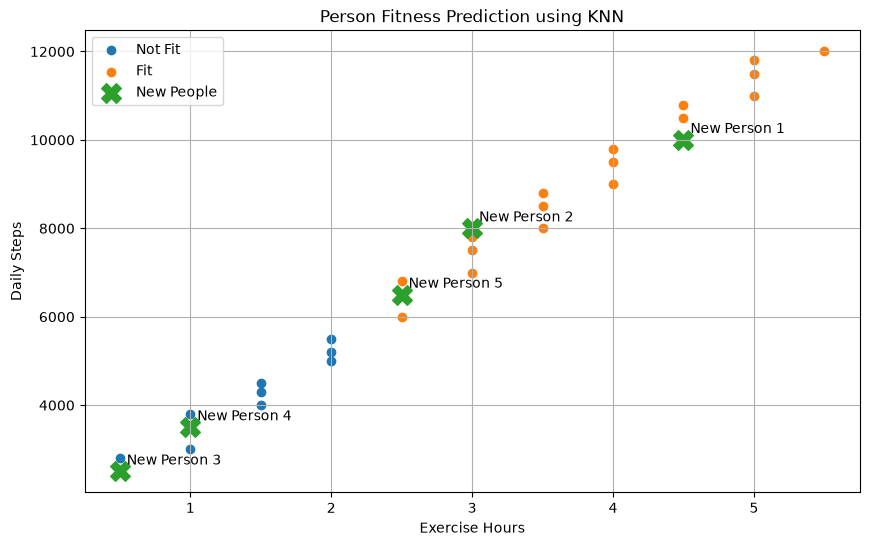

In [24]:
# Data visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Not Fit = 0
not_fit = df[df["Fit"] == 0]

plt.scatter(
    not_fit["Exercise_Hours"],
    not_fit["Daily_Steps"],
    label="Not Fit"
)

# Fit = 1
fit = df[df["Fit"] == 1]

plt.scatter(
    fit["Exercise_Hours"],
    fit["Daily_Steps"],
    label="Fit"
)

# New People
plt.scatter(
    new_people["Exercise_Hours"],
    new_people["Daily_Steps"],
    marker="X",
    s=200,
    label="New People"
)

# Add names
for _, person in new_people.iterrows():
    plt.annotate(
        person["Person"],
        (person["Exercise_Hours"], person["Daily_Steps"]),
        xytext=(5, 5),
        textcoords="offset points"
    )

plt.xlabel("Exercise Hours")
plt.ylabel("Daily Steps")
plt.title("Person Fitness Prediction using KNN")

plt.legend()
plt.grid(True)

plt.show()